### 1. Load a csv dataset and perform basic EDA(head, info, describe)

In [28]:
import pandas as pd

In [29]:
#Load the dataset
df=pd.read_csv("vgsalesGlobale.csv")

In [30]:
#Perform EDA
print(df.head())
print("\n\n",df.info())
print("\n\n",df.describe())

   Rank                      Name Platform    Year         Genre Publisher  \
0     1                Wii Sports      Wii  2006.0        Sports  Nintendo   
1     2         Super Mario Bros.      NES  1985.0      Platform  Nintendo   
2     3            Mario Kart Wii      Wii  2008.0        Racing  Nintendo   
3     4         Wii Sports Resort      Wii     NaN        Sports  Nintendo   
4     5  Pokemon Red/Pokemon Blue       GB  1996.0  Role-Playing  Nintendo   

   NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales  
0     41.49     29.02      3.77         8.46         82.74  
1     29.08      3.58      6.81         0.77         40.24  
2     15.85     12.88      3.79         3.31         35.82  
3     15.75     11.01      3.28         2.96         33.00  
4     11.27      8.89     10.22         1.00         31.37  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------  

### 2. Handle Missing values using multiple strategies

In [31]:
print(df.isnull().sum())

Rank              0
Name              0
Platform          0
Year            293
Genre             0
Publisher        81
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64


In [32]:

print(df['Year'].fillna(df['Year'].median(), inplace=True))
print(df['Publisher'].fillna('Unknown', inplace=True))

None
None


C:\Users\rabin\AppData\Local\Temp\ipykernel_12372\2808224574.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  print(df['Year'].fillna(df['Year'].median(), inplace=True))
C:\Users\rabin\AppData\Local\Temp\ipykernel_12372\2808224574.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a cop

### 3.Delete and remove duplicate rows


In [33]:
df = df.drop_duplicates()

### 4.Perform Label Encoding and One-Hot Encoding

In [34]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Platform'] = le.fit_transform(df['Platform'])
df['Genre'] = le.fit_transform(df['Genre'])
df['Publisher'] = le.fit_transform(df['Publisher'])

In [44]:
from sklearn.preprocessing import OneHotEncoder 
df1=df.copy()

ohe = OneHotEncoder(sparse_output=False, drop='first')

encoded = ohe.fit_transform(df1[['Name']])

encoded_df1 = pd.DataFrame(encoded, columns=ohe.get_feature_names_out())

df1 = df1.drop(['Name'], axis=1)
df1 = pd.concat([df1, encoded_df1], axis=1)

### 5.Create visualizations(bar,line,scatter)

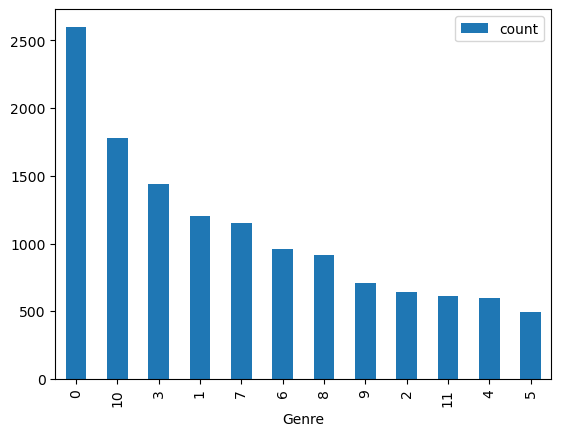

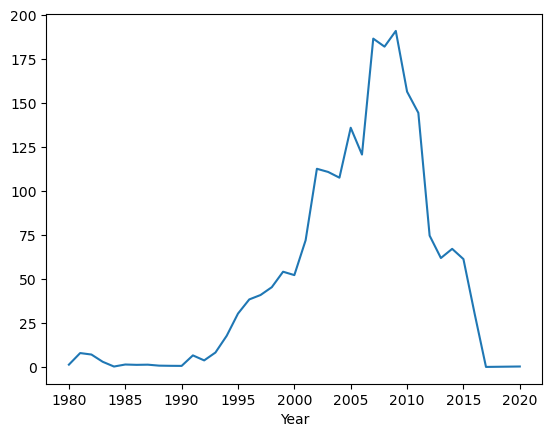

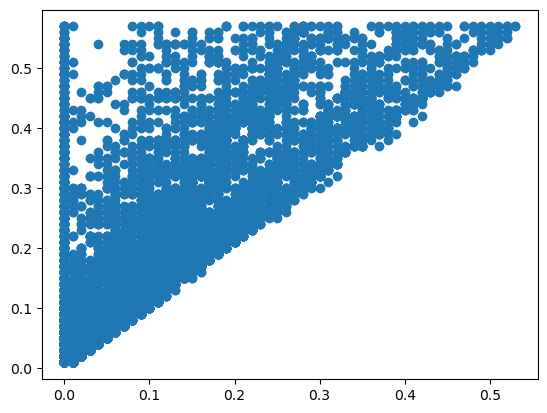

In [ ]:
import matplotlib.pyplot as plt

# Top genres
df['Genre'].value_counts().plot(kind='bar')
plt.show()

# Sales trend
df.groupby('Year')['Global_Sales'].sum().plot()
plt.show()

# Scatter
plt.scatter(df['NA_Sales'], df['Global_Sales'])
plt.show()

### 6.Identify and treat outliers using boxplot

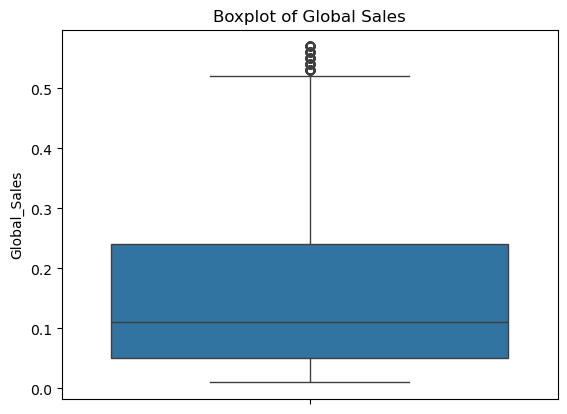

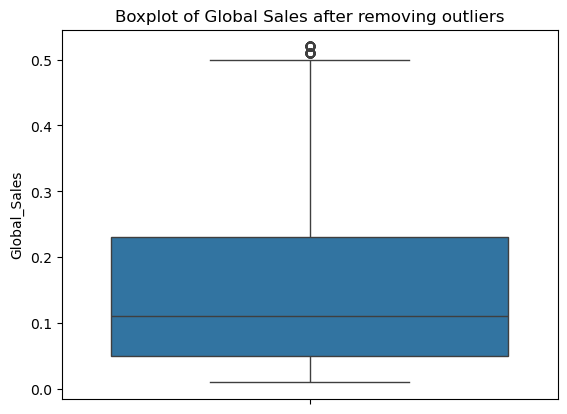

In [47]:
import seaborn as sns

sns.boxplot(df['Global_Sales'])
plt.title("Boxplot of Global Sales")
plt.show()

Q1 = df['Global_Sales'].quantile(0.25)
Q3 = df['Global_Sales'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['Global_Sales'] >= Q1 - 1.5*IQR) & 
        (df['Global_Sales'] <= Q3 + 1.5*IQR)]

sns.boxplot(df['Global_Sales'])
plt.title("Boxplot of Global Sales after removing outliers")
plt.show()

### 7.Perform Feature engineering(create new columns)

In [55]:
# Total regional sales check (sanity feature)
df['Total_Sales'] = df['NA_Sales'] + df['EU_Sales'] + df['JP_Sales'] + df['Other_Sales']

# Sales ratio
df['NA_ratio'] = df['NA_Sales'] / df['Global_Sales']

# Target variable creation (binary classification)
df['target'] = (df['Global_Sales'] > df['Global_Sales'].median()).astype(int)

In [56]:
print(df.head())

      Rank                                   Name  Platform    Year  Genre  \
3822  3824               Mario Tennis: Power Tour         6  2005.0     10   
3823  3825                                 Seaman         3  1999.0      9   
3824  3826  Guinness World Records: The Videogame         4  2008.0      0   
3825  3827                             The Grinch        15  1999.0      1   
3826  3828                          GT Pro Series        26  2006.0      6   

      Publisher  NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales  \
3822        359  1.746235  1.071600  2.170775    -0.070749      2.752067   
3823        446 -0.821564 -0.637870  6.694425    -0.573466      2.752067   
3824        549  4.207043 -0.447929 -0.433751     1.437404      2.752067   
3825        275  2.281193  3.160953 -0.433751     0.934687      2.752067   
3826        525  4.100051 -0.447929 -0.159591     1.437404      2.752067   

      Total_Sales  NA_ratio  target  
3822     4.917861  0.634518       1 

### 8.Apply Normalization and standarization

In [57]:
#Apply Standarization (used for algorithms like Logistic Regression, SVM, KNN , Decision Tree)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

cols = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']

df[cols] = scaler.fit_transform(df[cols])

print(df[cols].head())

      NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales
3822  1.746235  1.071600  2.170775    -0.070749      2.752067
3823 -0.821564 -0.637870  6.694425    -0.573466      2.752067
3824  4.207043 -0.447929 -0.433751     1.437404      2.752067
3825  2.281193  3.160953 -0.433751     0.934687      2.752067
3826  4.100051 -0.447929 -0.159591     1.437404      2.752067


In [59]:
#Apply Normalization(used for algorithms like Neural Networks,K-Means, PCA)
from sklearn.preprocessing import MinMaxScaler

df2=df.copy()

scaler = MinMaxScaler()

cols = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']

df2[cols] = scaler.fit_transform(df2[cols])

print(df2[cols].head())

      NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales
3822  0.500000  0.187500  0.365385     0.025641           1.0
3823  0.000000  0.000000  1.000000     0.000000           1.0
3824  0.979167  0.020833  0.000000     0.102564           1.0
3825  0.604167  0.416667  0.000000     0.076923           1.0
3826  0.958333  0.020833  0.038462     0.102564           1.0


### 9.Split dataset into train/test

In [61]:
from sklearn.model_selection import train_test_split


X = df.drop(['Name','target'], axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)  #70-30 Split due to large dataset size

### 10. Train a logistic Regression Model and evaluate

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

pred = lr.predict(X_test)
print("Model's Accuracy:", accuracy_score(y_test, pred))

print("Confusion Matrix:\n", confusion_matrix(y_test, pred))
print("Classification Report:\n", classification_report(y_test, pred))


Model's Accuracy: 0.9976519697364988
Confusion Matrix:
 [[1969    6]
 [   3 1855]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1975
           1       1.00      1.00      1.00      1858

    accuracy                           1.00      3833
   macro avg       1.00      1.00      1.00      3833
weighted avg       1.00      1.00      1.00      3833



### 11.Implement Decision Tree and compare results

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)
print("DT Accuracy:", accuracy_score(y_test, pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred_dt))
print("Classification Report:\n", classification_report(y_test, pred_dt))

DT Accuracy: 1.0
Confusion Matrix:
 [[1975    0]
 [   0 1858]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1975
           1       1.00      1.00      1.00      1858

    accuracy                           1.00      3833
   macro avg       1.00      1.00      1.00      3833
weighted avg       1.00      1.00      1.00      3833



### Comparision of Logistic Regression and Decision Tree MOdel 
 * Accuracy of Decision Tree > Accuracy of Logistic Regression
 * Decision Tree Model Has 0 False Negative and 0 False Positive  i.e This Model has 100% accuracy 
 * So, Decision Tree is more suitable than Logistic Regression for this dataset

### 12. Apply K-Means clustering and use Elbow method

c:\Users\rabin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\rabin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\rabin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\rabin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

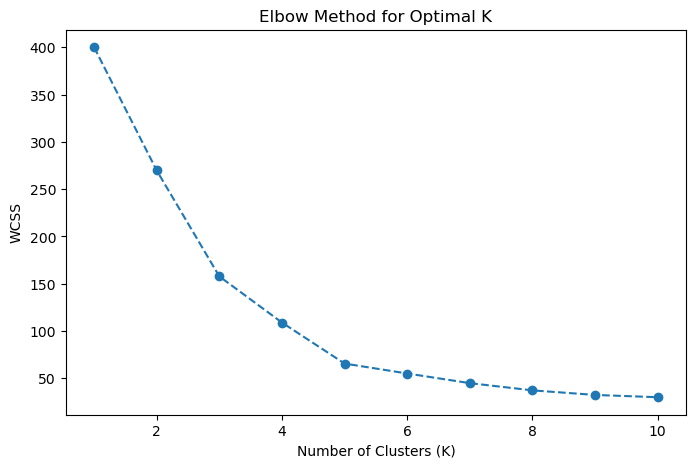

In [73]:
from sklearn.cluster import KMeans

df3=pd.read_csv("Mall_Customers.csv")
# Selecting relevant features

X = df3[['Annual Income (k$)', 'Spending Score (1-100)']]

# Standardizing the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Finding optimal K using Elbow Method
wcss = []
k_values = range(1, 11)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, wcss, marker='o', linestyle='--')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal K")
plt.show()



c:\Users\rabin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


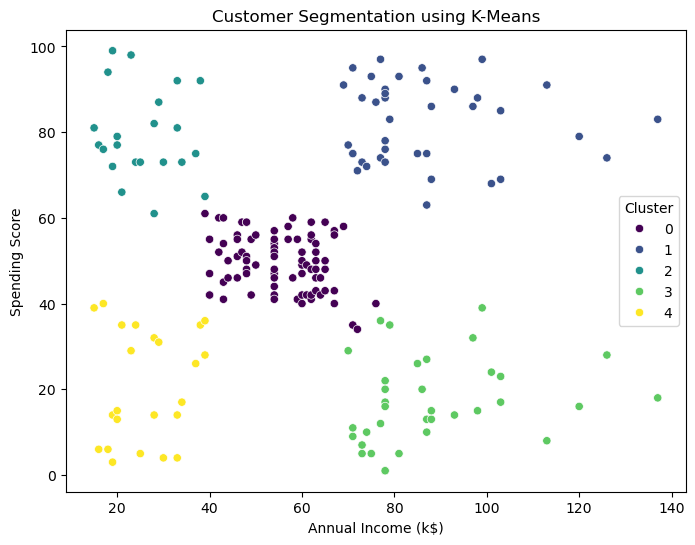

In [74]:
# Applying K-Means with K=5
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df3['Cluster'] = kmeans.fit_predict(X_scaled)

# Visualizing Clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df3['Annual Income (k$)'], y=df3['Spending Score (1-100)'], hue=df3['Cluster'], palette='viridis')
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation using K-Means")
plt.show()